In [42]:
import matplotlib.pyplot as plt
import json
import os
import numpy as np
import pandas as pd
from tabulate import tabulate

In [ ]:
PATH = "/home/ray/Documents/icccn-lstm/training_logs"
TYPES = {"lstm": "LSTM", "gru": "GRU", "rnn": "SimpleRNN"}
RATS = {"dsrc": "DSRC", "pc5": "C-V2X PC5", "5g": "5G SA"}


In [54]:
def plot_losses(types, rats):

    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
    i, j = 0, 0

    for rat in rats:
        for type in types:
            with open(os.path.join(PATH, type + "_" + rat + "_training_history.json"), "r") as f:
                history = json.load(f)

                # RMSE
                train_rmse = np.sqrt(history['loss'])
                val_rmse = np.sqrt(history['val_loss'])

                ax = axes[i, j]
                ax.plot(train_rmse, label='Training Loss')
                ax.plot(val_rmse, label='Validation Loss')
                ax.set_xlabel('Epochs')
                ax.set_ylabel('RMSE')
                ax.legend()
                ax.set_title(rats[rat] + " - " + types[type])
            j += 1
        i += 1
        j= 0

    fig.suptitle("Training vs Validation Loss (RMSE)")
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(os.path.join(PATH,"training_loss_grid.png"), dpi=600)
    fig.show()


def table_epochs(types, rats):
    summary_data = []
    i, j = 0, 0

    for rat in rats:
        for type in types:
            file_idx = i * 3 + j  # Map row/col to file index
            df = pd.read_csv(os.path.join(PATH, type + "_" + rat + "_training_log.csv"))

            # Extract summary statistics
            train_loss_final = df["Train Loss"].iloc[-1]
            val_loss_final = df["Val Loss"].iloc[-1]
            train_rmse_final = df["Train RMSE"].iloc[-1]
            val_rmse_final = df["Val RMSE"].iloc[-1]

            best_idx = df["Val Loss"].idxmin()  # Best epoch (lowest val loss)
            best_val_loss = df["Val Loss"].min()
            best_val_rmse = df["Val RMSE"].iloc[best_idx]
            best_epoch = df["Epoch"].iloc[best_idx]

            avg_epoch_time = df["Time (seconds)"].mean()
            fastest_training_time = df["Time (seconds)"].min()
            total_training_time = df["Time (seconds)"].sum()

            # Store results
            summary_data.append([
                rat, type, best_epoch, best_val_loss, best_val_rmse,
                train_loss_final, val_loss_final, train_rmse_final, val_rmse_final,
                avg_epoch_time, fastest_training_time, total_training_time
            ])

            j += 1
        i += 1
        j= 0

    # Create DataFrame
    summary_df = pd.DataFrame(summary_data, columns=[
        "RAT", "Model type", "Best Epoch", "Best Val Loss", "Best Val RMSE",
        "Final Train Loss", "Final Val Loss", "Final Train RMSE", "Final Val RMSE",
        "Avg Epoch Time (s)", "Fastest Training Time (s)", "Total Training Time (s)"
    ])

    # Display nicely formatted table in Jupyter
    summary_df.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [{'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center')]}]
    )

    summary_df.to_csv(os.path.join(PATH, "epoch_summary_table.csv"), index=False)

    return summary_df



In [55]:
epoch_table = table_epochs(TYPES, RATS)
print(tabulate(epoch_table, headers="keys", tablefmt="github"))


|    | RAT   | Model type   |   Best Epoch |   Best Val Loss |   Best Val RMSE |   Final Train Loss |   Final Val Loss |   Final Train RMSE |   Final Val RMSE |   Avg Epoch Time (s) |   Fastest Training Time (s) |   Total Training Time (s) |
|----|-------|--------------|--------------|-----------------|-----------------|--------------------|------------------|--------------------|------------------|----------------------|-----------------------------|---------------------------|
|  0 | dsrc  | lstm         |           82 |      4.86191    |       2.20497   |        11.2344     |       4.91679    |          3.35178   |        2.21738   |             20.6573  |                    19.1381  |                 1900.47   |
|  1 | dsrc  | gru          |           44 |      4.9066     |       2.21508   |        11.3869     |       5.00766    |          3.37445   |        2.23778   |             18.9164  |                    18.3031  |                 1002.57   |
|  2 | dsrc  | rnn          |   

/tmp/ipykernel_3500148/1571498361.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


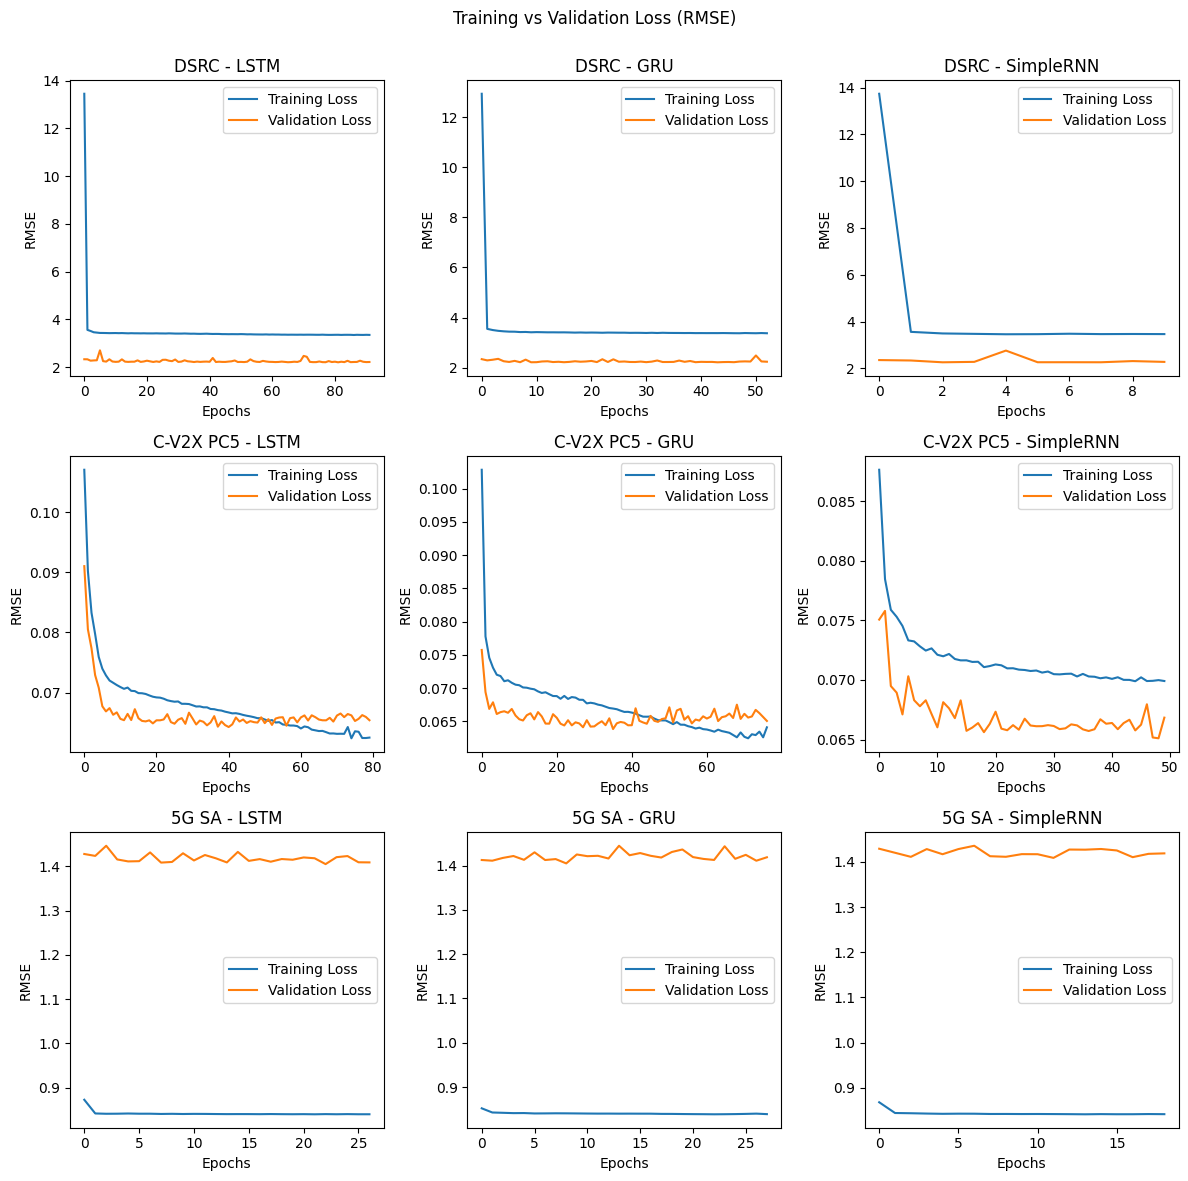

In [35]:
    # Plot losses
plot_losses(TYPES, RATS)